# Notebook 7: Training Tricks — Same Model, Better Training

**Goal:** Improve the SimpleCNN's accuracy without changing its architecture.

This demonstrates that **how you train** matters as much as **what you train**.
We use the exact same SimpleCNN from Notebook 4 but with:
1. **Heavier data augmentation** (ColorJitter, RandomErasing)
2. **CutMix & MixUp** (blend training images for better regularization)
3. **Label smoothing** (prevent overconfident predictions)
4. **Cosine annealing LR** (smoother learning rate decay)

---

## 7.1 Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.transforms import v2

from src.data_utils import get_cifar10_loaders_advanced, get_raw_cifar10, CIFAR10_CLASSES
from src.models import SimpleCNN, count_parameters
from src.train import train_model, evaluate, evaluate_with_probs
from src.visualize import (plot_training_curves, plot_confusion_matrix,
                           plot_per_class_accuracy, plot_misclassified, plot_roc_curves)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 7.2 The Training Tricks

| Trick | What it does | Why it helps |
|-------|-------------|-------------|
| **Heavier augmentation** | ColorJitter + RandomErasing | Forces model to be robust to color/occlusion |
| **CutMix** | Cuts a patch from one image and pastes it on another | Regularization — model sees mixed content |
| **MixUp** | Blends two images with a weighted average | Smooth decision boundaries between classes |
| **Label smoothing** | Targets become 0.9/0.01 instead of 1.0/0.0 | Prevents overconfident predictions |
| **Cosine annealing** | LR follows a cosine curve from high to low | Smoother decay than step-based schedules |

In [2]:
# Load data with heavier augmentation (ColorJitter + RandomErasing)
train_loader, test_loader = get_cifar10_loaders_advanced(
    batch_size=64, data_dir='../data', num_workers=0
)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

c:\Users\Prithvi Nair\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training batches: 782
Test batches: 157


In [3]:
# Set up CutMix and MixUp as batch-level transforms
cutmix = v2.CutMix(num_classes=10)
mixup = v2.MixUp(num_classes=10)
cutmix_or_mixup = v2.RandomChoice([cutmix, mixup])

# Wrap the train loader to apply CutMix/MixUp on each batch
def collate_fn(batch):
    return cutmix_or_mixup(*torch.utils.data.dataloader.default_collate(batch))

# Recreate train loader with the CutMix/MixUp collate function
train_loader_cutmix = torch.utils.data.DataLoader(
    train_loader.dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn
)

# Verify: CutMix/MixUp produces soft labels
images, labels = next(iter(train_loader_cutmix))
print(f"Batch shape: {images.shape}")
print(f"Labels shape: {labels.shape}  (soft labels — one-hot-ish, not integers)")
print(f"Sample label: {labels[0].numpy().round(2)}")

Batch shape: torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64, 10])  (soft labels — one-hot-ish, not integers)
Sample label: [0.   0.   0.   0.   0.   0.   0.   0.78 0.   0.22]


## 7.3 Model & Training Setup

In [4]:
# Same architecture as Notebook 4
model = SimpleCNN(num_classes=10)
print(f"Parameters: {count_parameters(model):,} (same as original SimpleCNN)")

# Training tricks:
# 1. Label smoothing — softens the targets (0.9 instead of 1.0)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 2. Same optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 3. Cosine annealing — smooth LR decay from 0.001 to near 0
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

print(f"Criterion: CrossEntropyLoss with label_smoothing=0.1")
print(f"Scheduler: CosineAnnealingLR (T_max=30)")

Parameters: 2,168,746 (same as original SimpleCNN)
Criterion: CrossEntropyLoss with label_smoothing=0.1
Scheduler: CosineAnnealingLR (T_max=30)


## 7.4 Training

In [5]:
history = train_model(
    model=model,
    train_loader=train_loader_cutmix,
    test_loader=test_loader,
    epochs=30,
    lr=0.001,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler
)

Training on: cuda
Epochs: 30, Learning Rate: 0.001
Model parameters: 2,168,746
------------------------------------------------------------
Epoch   1/30 | Train Loss: 2.1997 | Train Acc: 20.8% | Test Loss: 1.8808 | Test Acc: 39.0% | Time: 95.1s
Epoch   5/30 | Train Loss: 2.0610 | Train Acc: 31.5% | Test Loss: 1.5924 | Test Acc: 51.9% | Time: 87.4s
Epoch  10/30 | Train Loss: 1.9766 | Train Acc: 38.1% | Test Loss: 1.4405 | Test Acc: 61.6% | Time: 89.7s
Epoch  15/30 | Train Loss: 1.9248 | Train Acc: 42.7% | Test Loss: 1.3117 | Test Acc: 65.8% | Time: 77.5s
Epoch  20/30 | Train Loss: 1.8957 | Train Acc: 45.0% | Test Loss: 1.2769 | Test Acc: 68.5% | Time: 77.3s
Epoch  25/30 | Train Loss: 1.8689 | Train Acc: 46.3% | Test Loss: 1.2422 | Test Acc: 69.4% | Time: 77.4s
Epoch  30/30 | Train Loss: 1.8726 | Train Acc: 46.8% | Test Loss: 1.2279 | Test Acc: 69.9% | Time: 77.2s
------------------------------------------------------------
Best test accuracy: 69.9%
Total training time: 2504s (41.7 min)


In [6]:
torch.save(model.state_dict(), '../saved_models/cnn_tricks.pth')
print("Model saved to saved_models/cnn_tricks.pth")

Model saved to saved_models/cnn_tricks.pth


## 7.5 Training Curves

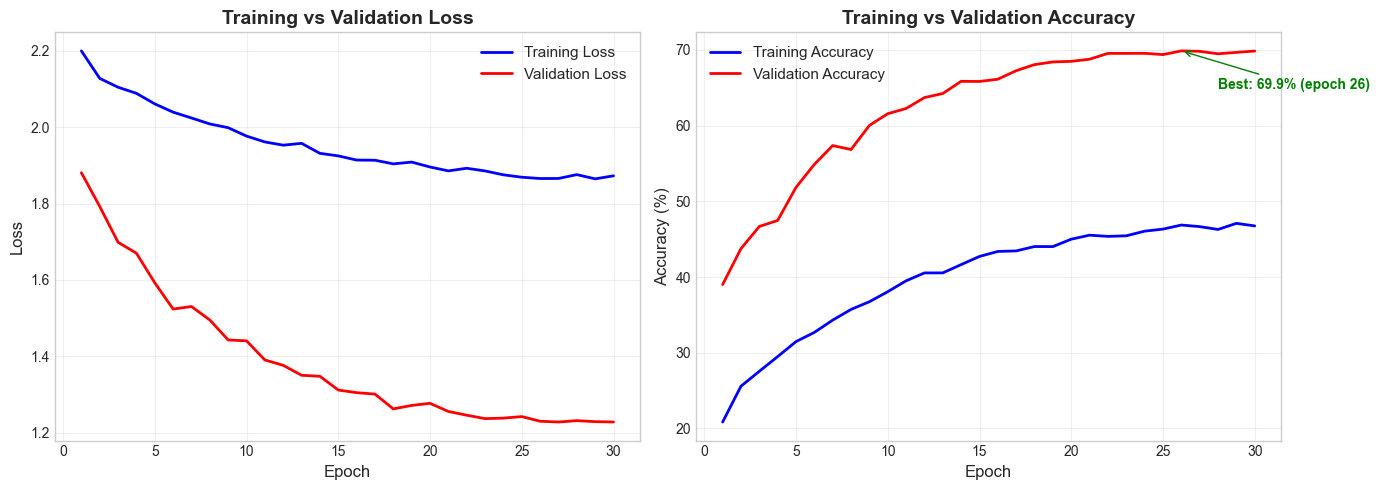

In [7]:
fig = plot_training_curves(history)
plt.show()

## 7.6 Test Set Evaluation

In [8]:
eval_criterion = nn.CrossEntropyLoss()
test_loss, test_acc, predictions, true_labels = evaluate(
    model, test_loader, eval_criterion, device
)

print(f"Final Test Results:")
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.2f}%")
print(f"  SimpleCNN baseline was: 80.34%")
print(f"  Improvement: +{test_acc - 80.34:.2f}%")

Final Test Results:
  Test Loss:     1.0050
  Test Accuracy: 69.86%
  SimpleCNN baseline was: 80.34%
  Improvement: +-10.48%


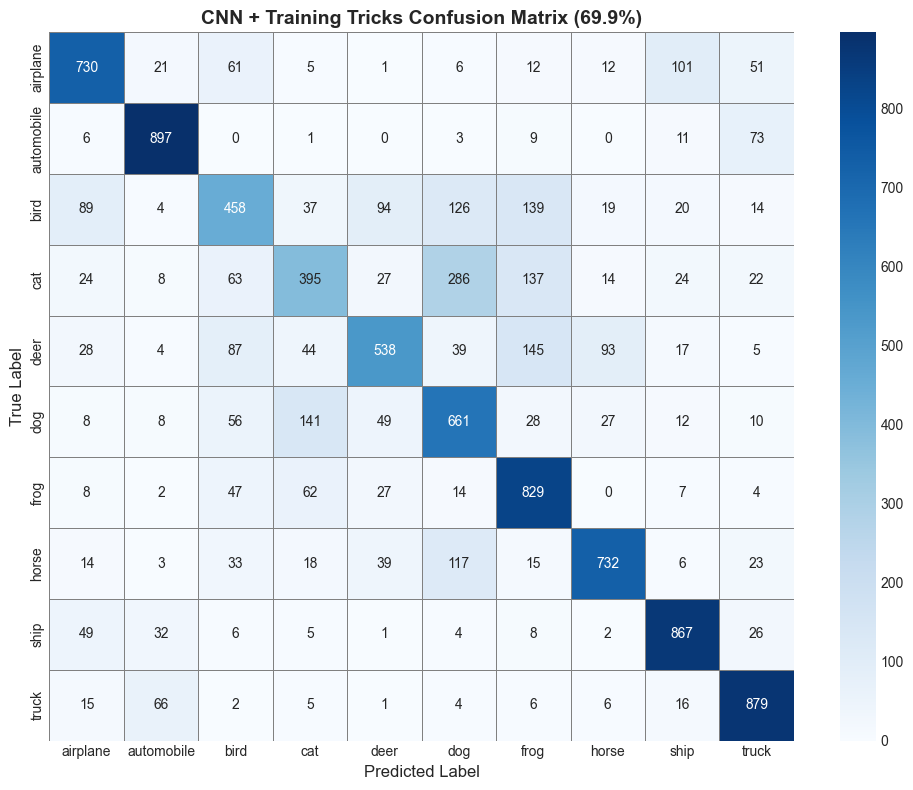

In [9]:
fig = plot_confusion_matrix(
    true_labels, predictions, CIFAR10_CLASSES,
    title=f'CNN + Training Tricks Confusion Matrix ({test_acc:.1f}%)'
)
plt.show()

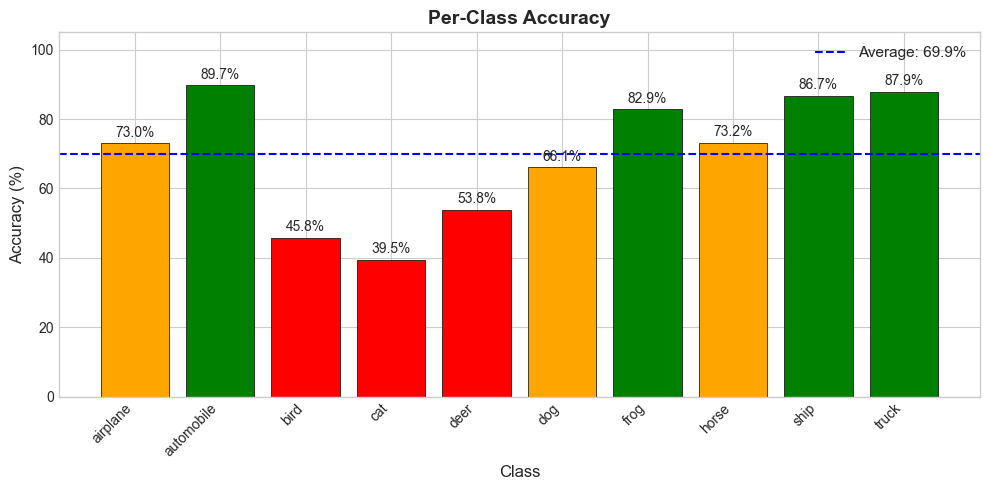

In [10]:
fig = plot_per_class_accuracy(true_labels, predictions, CIFAR10_CLASSES)
plt.show()

## 7.7 ROC Curves

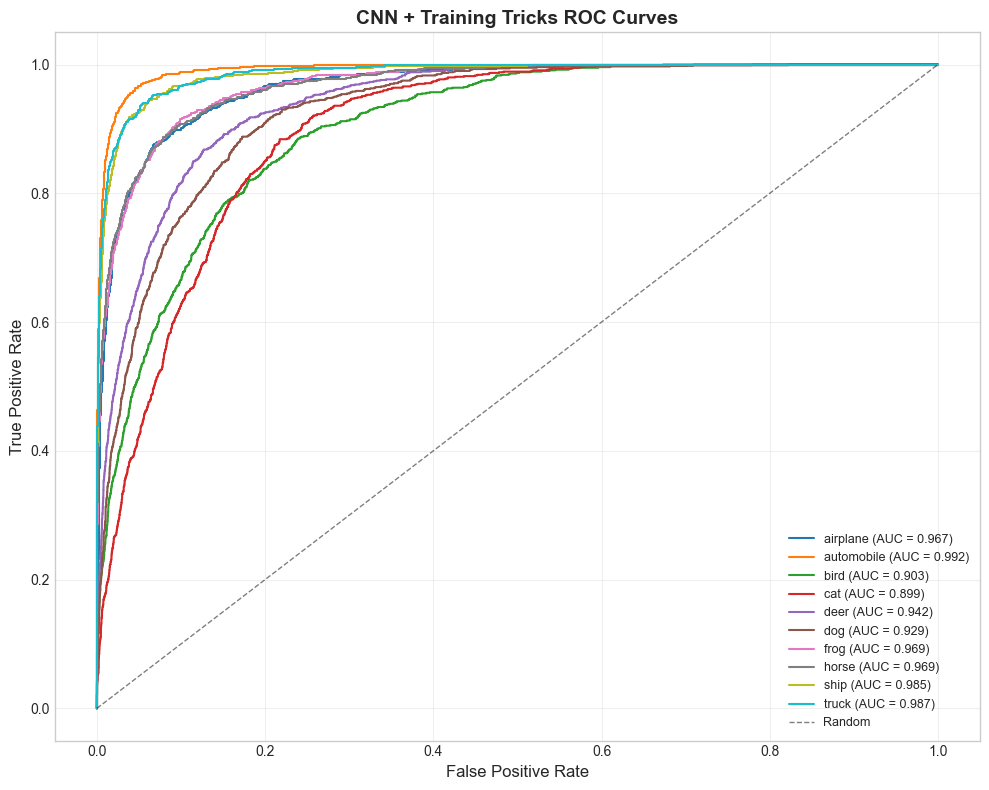

In [11]:
accuracy, preds, labels, probabilities = evaluate_with_probs(model, test_loader, device)

fig = plot_roc_curves(labels, probabilities, CIFAR10_CLASSES,
                      title='CNN + Training Tricks ROC Curves')
plt.show()

## 7.8 Save Results

In [12]:
import json

tricks_results = {
    'accuracy': test_acc,
    'total_time': sum(history['epoch_times']),
    'epochs': len(history['train_loss']),
    'predictions': predictions,
    'true_labels': true_labels,
    'probabilities': probabilities.tolist(),
    'history': {
        'train_loss': history['train_loss'],
        'train_acc': history['train_acc'],
        'test_loss': history['test_loss'],
        'test_acc': history['test_acc']
    },
    'n_parameters': count_parameters(model)
}

with open('../saved_models/cnn_tricks_results.json', 'w') as f:
    json.dump(tricks_results, f)

print(f"Results saved. Test accuracy: {test_acc:.2f}%")
print(f"Training time: {sum(history['epoch_times']):.0f}s ({sum(history['epoch_times'])/60:.1f} min)")

Results saved. Test accuracy: 69.86%
Training time: 2504s (41.7 min)


## 7.9 Summary

### Same model, different training:
- **Architecture:** Identical SimpleCNN (~2.2M parameters)
- **What changed:** Augmentation, CutMix/MixUp, label smoothing, cosine annealing
- **Takeaway:** Training strategy alone can improve accuracy by several percentage points
- A well-trained simple model can outperform a poorly-trained complex model